In [1]:
%load_ext autoreload
%autoreload 2
from arboreto.algo import genie3, grnboost2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from genecompass.grn import parallel_grn, protia1
from genecompass.exppc import percentile_analysis, vectorized_correlation
from genecompass.utils import fimo_filter
from genecompass.io_utils import for_datafream
from sklearn.preprocessing import StandardScaler

- motif_scan_res 的结果请使用./genecompass/mscan_utils.py 或者 ./genecompass/fimo_scan.py 脚本进行

In [2]:
motif_scan_res = pd.read_csv('odata/rosa_chinensis/8_Rose_Motif_scan_double_rename.csv', index_col=0) 
motif_infos = pd.read_csv('meme/motif_infos.txt')
rna_seq = pd.read_csv('odata/rosa_chinensis/transcript_rowname_FPKM.csv', index_col=0) #row=gene, columns=samples

In [3]:
rna_seq.index =  [i.replace('mRNA:RchiOBHm', 'RchiOBHm_') for i in rna_seq.index]
rna_seq.head()

,FPKM.botrytisGeneration1_12h_1,FPKM.botrytisGeneration1_12h_2,FPKM.botrytisGeneration18_12h_1,FPKM.botrytisGeneration18_12h_2,FPKM.botrytisGeneration9_12h_1,FPKM.botrytisGeneration9_12h_2,FPKM.botrytisTime18h_1,FPKM.botrytisTime18h_2,FPKM.botrytisTime18h_3,FPKM.botrytisTime18h_PDB_1,...,FPKM.ynaasBCT36_3,FPKM.ynaasBCT60_1,FPKM.ynaasBCT60_2,FPKM.ynaasBCT60_3,FPKM.ynaasBCT72_1,FPKM.ynaasBCT72_2,FPKM.ynaasBCT72_3,FPKM.ynaasCK_1,FPKM.ynaasCK_2,FPKM.ynaasCK_3
RchiOBHm_CPg0501671,0.000000,0.047660,0.107558,0.314658,0.115230,0.123891,0.681636,0.250044,0.061241,0.768589,...,0.350090,0.000000,0.103765,0.044905,0.122453,0.060566,0.118783,0.000000,0.000000,0.000000
RchiOBHm_CPg0501681,0.000000,0.056736,0.019709,0.065409,0.008764,0.020846,0.338374,0.566132,0.245167,0.334787,...,0.047848,0.000000,0.019776,0.000000,0.000000,0.000000,0.050950,0.000000,0.000000,0.000000
ncRNA:RchiOBHmCPg0501691,0.032703,0.102548,0.069630,0.023379,0.066978,0.034741,0.265499,0.273760,0.203366,0.235665,...,0.080790,0.068406,0.068196,0.022448,0.072188,0.172981,0.065549,0.000000,0.000000,0.010027
ncRNA:RchiOBHmCPg0501701,0.000000,0.000000,0.000000,0.121182,0.000000,0.000000,0.000000,0.680115,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.408998,0.000000,0.000000,0.416652,0.000000,0.000000,0.157234
ncRNA:RchiOBHmCPg0501711,0.786989,1.442919,3.499798,1.777022,1.098893,1.683217,3.861066,3.991443,3.119437,2.691051,...,2.720925,5.081007,2.719013,2.949951,3.109938,8.409573,5.176015,4.144379,2.640882,3.215413


In [4]:
tf_infos = pd.read_csv('odata/rosa_chinensis/rose_tf(protein).txt', sep='\t', index_col=0,)
tfs = [i.replace('RcHm_v2.0_', 'RchiOBHm_') for i in tf_infos['Gene_ID'].tolist()]
tf =  'RchiOBHm_Chr3g0461481'

In [5]:
tf_infos.index = tf_infos['Gene_ID'].apply(lambda x: x.replace('RcHm_v2.0_', 'RchiOBHm_'))
tf_infos['Gene_ID']= tf_infos['Gene_ID'].apply(lambda x: x.replace('RcHm_v2.0_','RchiOBHm_'))
tf_infos.head()

,Gene_ID,Family
Gene_ID,,
RchiOBHm_Chr0c19g0499991,RchiOBHm_Chr0c19g0499991,WOX
RchiOBHm_Chr0c19g0500021,RchiOBHm_Chr0c19g0500021,WOX
RchiOBHm_Chr0c19g0500091,RchiOBHm_Chr0c19g0500091,NAC
RchiOBHm_Chr0c19g0500131,RchiOBHm_Chr0c19g0500131,WOX
RchiOBHm_Chr0c19g0500151,RchiOBHm_Chr0c19g0500151,C2H2


In [6]:
valid_genes = [
    'RchiOBHm_Chr4g0395841', #^
    'RchiOBHm_Chr7g0201401', #^
    'RchiOBHm_Chr1g0378151', # 
    'RchiOBHm_Chr3g0486621',
    'RchiOBHm_Chr2g0160251',
    'RchiOBHm_Chr4g0424041',#
    'RchiOBHm_Chr2g0097821',
    'RchiOBHm_Chr1g0359311',#
    'RchiOBHm_Chr3g0484691',#
    'RchiOBHm_Chr6g0285101'#
]

# RchiOBHm_Chr1g0378151
# RchiOBHm_Chr4g0424041
# RchiOBHm_Chr1g0359311
# RchiOBHm_Chr3g0484691
# RchiOBHm_Chr6g0285101
no_valid_genes = ['RchiOBHm_Chr4g0434051', 'RchiOBHm_Chr5g0081451', 'RchiOBHm_Chr6g0264401',
                'RchiOBHm_Chr4g0406271','RchiOBHm_Chr4g0425171','RchiOBHm_Chr5g0004291',
                'RchiOBHm_Chr5g0076921','RchiOBHm_Chr2g0150351','RchiOBHm_Chr2g0167751',
                'RchiOBHm_Chr3g0481541','RchiOBHm_Chr4g0392501','RchiOBHm_Chr5g0018151',
                'RchiOBHm_Chr5g0027831', 'RchiOBHm_Chr5g0061451','RchiOBHm_Chr6g0247731',
                'RchiOBHm_Chr6g0288231','RchiOBHm_Chr7g0177961','RchiOBHm_Chr7g0212481',
                'RchiOBHm_Chr3g0482711',]

In [7]:
rna_seq_t = rna_seq.T
data = rna_seq_t[rna_seq_t[tf]>0].T

### STEP1: 计算TF与所有的TG间的皮尔逊相关性

In [8]:
correlations, p_values = vectorized_correlation(data.loc[tf,:].to_numpy(), 
                                                data.to_numpy())
pcc_net = pd.DataFrame(
    np.stack([correlations, p_values], axis=0),
    columns=data.index,
    index = ['cor', 'pvalues']
).T.dropna()

c:\Users\ABCD\Desktop\regulon\genecompass\exppc.py:24: RuntimeWarning: invalid value encountered in divide
  correlations = cov / (std_matrix * std_target)
c:\Users\ABCD\Desktop\regulon\genecompass\exppc.py:27: RuntimeWarning: invalid value encountered in sqrt
  t_values = correlations * np.sqrt((n - 2) / (1 - correlations**2))


### STEP2: 计算cor的概率密度图，获取双峰（0.025）的值
- 获取pcc genes

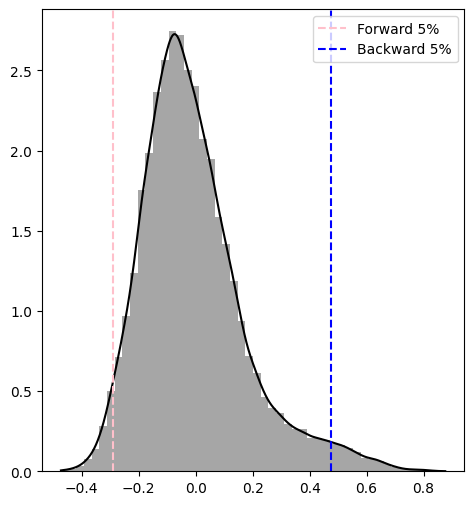

In [9]:
analysis = percentile_analysis(pcc_net['cor'], alpha=.025)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(pcc_net['cor'], bins=50, density=True, alpha=0.7, color='gray')
plt.plot(analysis['density']['x'], analysis['density']['y'], 'k-',)
plt.axvline(analysis['percentiles']['lower'], color='pink', linestyle='--', label='Forward 5%')
plt.axvline(analysis['percentiles']['upper'], color='b', linestyle='--', label='Backward 5%')
plt.legend()
plt.show()

In [10]:
indices = np.concatenate([analysis['indices']['lower'], analysis['indices']['upper']])
filtered_pcc_net = pcc_net.iloc[indices, :]
pcc_genes =  filtered_pcc_net.index.tolist()
pcc_genes = pcc_genes + [tf] if tf not in pcc_genes else pcc_genes

In [11]:
pcc_net[pcc_net.index.isin(pcc_genes)].to_csv('pcc_genes.csv')

In [12]:
zscaler = StandardScaler()
zdata = zscaler.fit_transform(
    X=data.T.loc[:, pcc_genes])

In [13]:
pd_zdata = pd.DataFrame(
    data=zdata, 
    columns=pcc_genes,
    index = data.columns
)
pd_zdata.shape

(184, 2421)

# STEP3: 使用MOTIF SCAN 的结果过滤下游基因
- pcc gene -> fimo gene

In [14]:
tg2tfs_dct = {}
need_tfs = [t for t in tfs if t in pcc_genes]
for tg in pcc_genes:
    tg2tfs_dct[tg] = need_tfs
len(tg2tfs_dct)

2421

In [15]:
fimo_genes = fimo_filter(
    tf='RchiOBHm_Chr3g0461481', 
    motif_infos=motif_infos,
    pcc_genes=pcc_genes,
    motif_scan_res=motif_scan_res,
    fimo_score=8,
    tf_f = 'WRKY'
)

--- Running FIMO Filter ---
After FIMO filtering, 1268 genes remain.


### STEP4: protia 算法进行GRN推断

In [16]:
protia_net = protia1(
    expression_data=pd_zdata.loc[:, fimo_genes],
    tf_names = [t for t in fimo_genes if t in tfs]
)

Gene expression matrix of shape (184, 1268)


c:\Users\ABCD\Desktop\regulon\genecompass\portia\portia\core.py:138: UserWarning: Expression data contain negative values. It is recommended to provide raw data instead.
  warnings.warn(


In [17]:
tf_net = for_datafream(protia_net, tf)
tf_net.to_csv('protial.csv')

In [18]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # ---------- 基本参数 ----------
# plt.Figure(figsize=(4,4), dpi=800)
# # axs = axs.flatten()          # 8 个子轴
# custom_palette = {0: '#8b938e', 2:"#a0d911", 3:'#531dab'}
# custom_size    = {0: 34, 2:54, 3:54}   # 备用，如果你想手工映射面积

# ax = sns.scatterplot(
#     data=protia_net1,
#     x='rank',
#     y='abs_importance',
#     hue='label',
#     palette=custom_palette,
#     size='label',
#     # sizes=(custom_size[0], custom_size[1]),
#     edgecolor='black',
#     linewidth=0.3,
# )
# plt.grid(True, axis='both', linestyle='--', linewidth=1, color='gray', alpha=0.5)
# handles, _ = ax.get_legend_handles_labels()
# plt.legend(handles, ['No Test', 'Experiment Validation Interaction',
#                       'Experiment Validation No Interaction'],
#             title='Validation Status', loc='best', fontsize=12,)
# plt.savefig(f'{tf}_importance_subplots.png', dpi=800)
# ax.set_ylabel('Importance Score', fontsize=14, fontname='Arial')
# ax.set_xlabel('Rank', fontsize=14, fontname='Arial')
# idx = 0
# for i in protia_net1.itertuples():
#     if i.label != 0:
#         if idx % 2 ==0:
#             x1 = 0
#             y1 = -.12
#         else:
#             x1 = 0
#             y1 = .09
#         gene_name = i.Index
#         x = i.rank
#         y = i.abs_importance
#         plt.annotate(
#             gene_name,                  # 文字内容
#             xy=(x, y),               # 箭头尖端**落在图上的坐标**
#             xytext=(x+x1, y+y1),           # 文字**起点**坐标
#             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
#             fontsize=10,
#             color='black'
#         )
#         idx+=1
# plt.savefig(f'{tf}_socre_1200.png', dpi=800)